In [ ]:
print("Notebook başladı ✓")

Notebook başladı ✓


In [ ]:

import os
os.environ['KAGGLE_USERNAME'] = "hseynkaba"
os.environ['KAGGLE_KEY'] = "04624343bce2f71d4270ad2ce956a228"

!pip install kaggle -q

!kaggle datasets download -d berkaykocaoglu/tr-sign-language -p ./data --unzip

print("Dataset indirildi ✓")


print("\n--- Data Directory Contents ---")
!ls -R ./data
print("-------------------------------")

Görüntülenen çıkış son 5000 satıra kısaltıldı.
space1371.jpg  space1911.jpg  space2451.jpg  space2992.jpg  space830.jpg
space1372.jpg  space1912.jpg  space2452.jpg  space2993.jpg  space831.jpg
space1373.jpg  space1913.jpg  space2453.jpg  space2994.jpg  space832.jpg
space1374.jpg  space1914.jpg  space2454.jpg  space2995.jpg  space833.jpg
space1375.jpg  space1915.jpg  space2455.jpg  space2996.jpg  space834.jpg
space1376.jpg  space1916.jpg  space2456.jpg  space2997.jpg  space835.jpg
space1377.jpg  space1917.jpg  space2457.jpg  space2998.jpg  space836.jpg
space1378.jpg  space1918.jpg  space2458.jpg  space2999.jpg  space837.jpg
space1379.jpg  space1919.jpg  space2459.jpg  space299.jpg   space838.jpg
space137.jpg   space191.jpg   space245.jpg   space29.jpg    space839.jpg
space1380.jpg  space1920.jpg  space2460.jpg  space2.jpg     space83.jpg
space1381.jpg  space1921.jpg  space2461.jpg  space3000.jpg  space840.jpg
space1382.jpg  space1922.jpg  space2462.jpg  space300.jpg   space841.jpg
space

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import alexnet
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

print("Kütüphaneler yüklendi ✓")

Kütüphaneler yüklendi ✓


In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder("data/tr_signLanguage_dataset/train", transform=transform)
test_data  = datasets.ImageFolder("data/tr_signLanguage_dataset/test", transform=transform)

classes = train_data.classes
num_classes = len(classes)

print("Sınıf sayısı:", num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = alexnet(weights="IMAGENET1K_V1")
for p in model.features.parameters():
    p.requires_grad = False

model.classifier[6] = nn.Linear(4096, num_classes)
model = model.to(device)

crit = nn.CrossEntropyLoss()
opt = optim.Adam(model.classifier.parameters(), lr=0.001)

print("Model hazır ✓")


Sınıf sayısı: 26
Device: cpu
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:00<00:00, 311MB/s]


Model hazır ✓


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = alexnet(weights='IMAGENET1K_V1')
for p in model.features.parameters():
    p.requires_grad = False

model.classifier[6] = nn.Linear(4096, num_classes)
model = model.to(device)

crit = nn.CrossEntropyLoss()
opt = optim.Adam(model.classifier.parameters(), lr=0.001)

print("Model hazır ✓")

Device: cpu
Model hazır ✓


In [ ]:
batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

epochs = 3
print("Eğitim başlıyor...\n")

for epoch in range(1, epochs+1):
    print(f"Epoch {epoch}/{epochs}")
    model.train()
    loop = tqdm(train_loader)

    for x, y in loop:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        loop.set_postfix(loss=loss.item())

print("Eğitim bitti ✓")

Eğitim başlıyor...

Epoch 1/3


100%|██████████| 933/933 [05:57<00:00,  2.61it/s, loss=0.582]


Epoch 2/3


100%|██████████| 933/933 [05:51<00:00,  2.66it/s, loss=0.52]


Epoch 3/3


100%|██████████| 933/933 [06:00<00:00,  2.59it/s, loss=0.414]

Eğitim bitti ✓


Test başlıyor...


100%|██████████| 374/374 [01:27<00:00,  4.27it/s]


Accuracy: 0.9327558791530672
Precision: 0.935405354454937
Recall: 0.9327558791530672
F1: 0.9330566871749096
              precision    recall  f1-score   support

           A       0.93      0.94      0.94      1962
           B       0.96      0.98      0.97      1929
           C       0.95      0.94      0.95      1953
           D       0.94      0.91      0.93      1948
           E       0.99      0.88      0.93      1943
           F       0.95      0.93      0.94      1973
           G       0.90      0.96      0.93      1947
           H       0.95      0.95      0.95      1952
           I       0.92      0.94      0.93      1933
           J       0.84      0.92      0.88      1944
           K       0.97      0.94      0.95      1950
           L       0.92      0.91      0.92      1958
           M       0.87      0.91      0.89      1934
           N       0.88      0.87      0.88      1941
           O       0.98      0.90      0.94      1945
           P       0.99    

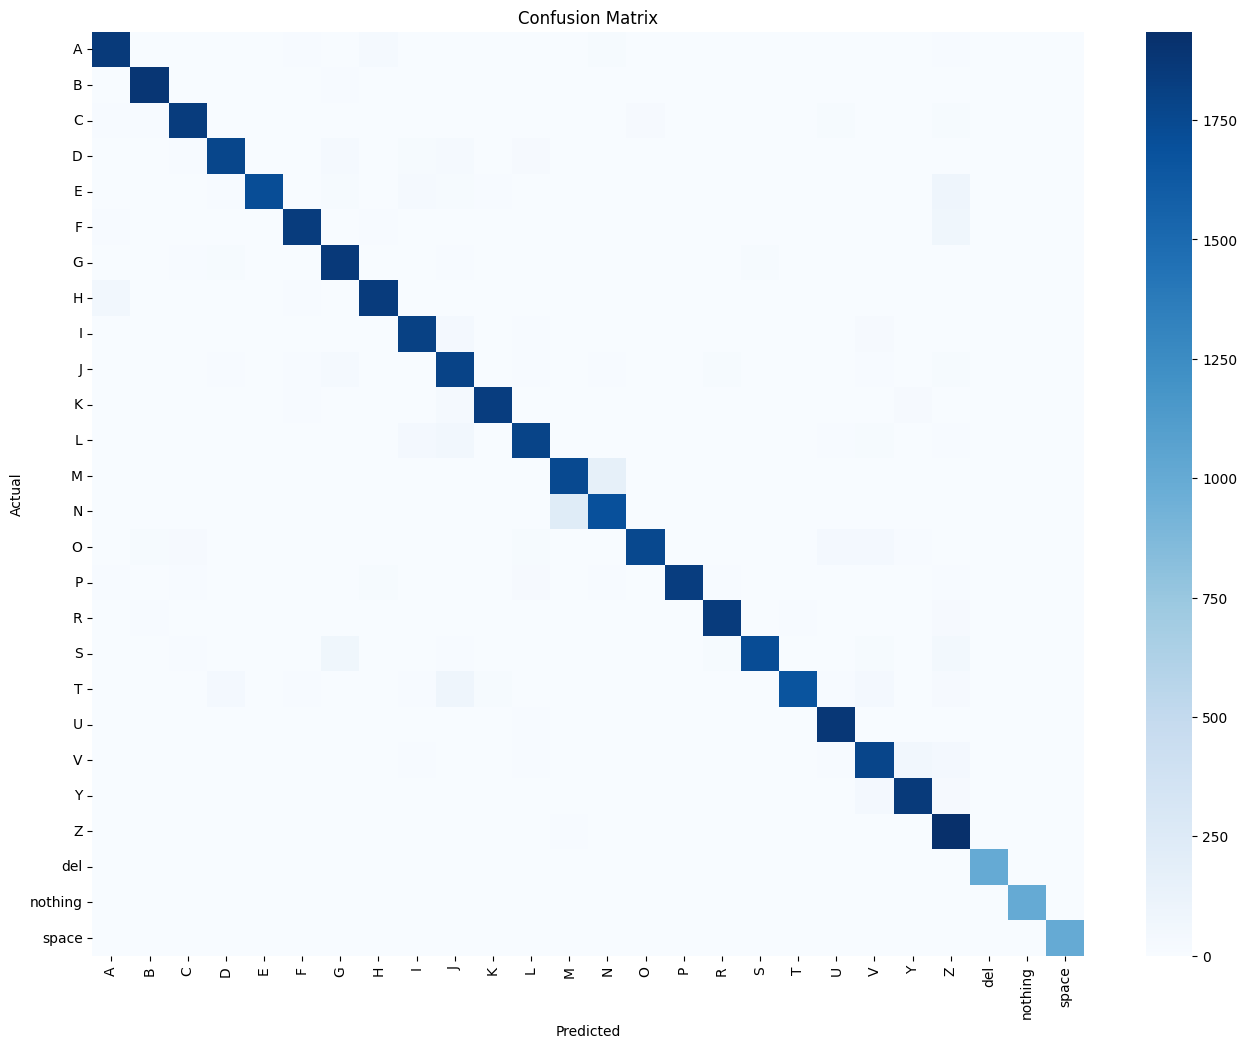

In [ ]:

print("Test başlıyor...")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device)
        out = model(x)
        _, preds = torch.max(out, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())


acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average="weighted")
rec = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

print(classification_report(all_labels, all_preds, target_names=classes))


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16,12))
sns.heatmap(cm, cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("Model ve Eğitim Ayarları Yeniden Yapılandırılıyor ✓")


model = alexnet(weights="IMAGENET1K_V1")
for p in model.features.parameters():
    p.requires_grad = False

model.classifier[6] = nn.Linear(4096, num_classes)
model = model.to(device)

crit = nn.CrossEntropyLoss()
opt = optim.Adam(model.classifier.parameters(), lr=0.001)


train_losses_history = []
test_losses_history = []
train_accuracies_history = []
test_accuracies_history = []

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

epochs = 3
print("Eğitim başlıyor...")

for epoch in range(1, epochs + 1):
    print(f"Epoch {epoch}/{epochs}")
    model.train()
    total_train_loss = 0
    correct_train_predictions = 0
    total_train_samples = 0

    loop = tqdm(train_loader)
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        total_train_loss += loss.item() * x.size(0)
        _, predicted = torch.max(out.data, 1)
        total_train_samples += y.size(0)
        correct_train_predictions += (predicted == y).sum().item()

        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / total_train_samples
    train_accuracy = correct_train_predictions / total_train_samples
    train_losses_history.append(avg_train_loss)
    train_accuracies_history.append(train_accuracy)


    model.eval()
    total_test_loss = 0
    correct_test_predictions = 0
    total_test_samples = 0

    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            out_test = model(x_test)
            loss_test = crit(out_test, y_test)

            total_test_loss += loss_test.item() * x_test.size(0)
            _, predicted_test = torch.max(out_test.data, 1)
            total_test_samples += y_test.size(0)
            correct_test_predictions += (predicted_test == y_test).sum().item()

    avg_test_loss = total_test_loss / total_test_samples
    test_accuracy = correct_test_predictions / total_test_samples
    test_losses_history.append(avg_test_loss)
    test_accuracies_history.append(test_accuracy)

    print(f"Epoch {epoch} - Avg Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Avg Test Loss: {avg_test_loss:.4f}, Test Acc: {test_accuracy:.4f}")

print("Eğitim bitti ✓")

SyntaxError: unterminated string literal (detected at line 25) (ipython-input-2243857740.py, line 25)

In [ ]:
print("Model ve Eğitim Ayarları Yeniden Yapılandırılıyor ✓")


model = alexnet(weights="IMAGENET1K_V1")
for p in model.features.parameters():
    p.requires_grad = False

model.classifier[6] = nn.Linear(4096, num_classes)
model = model.to(device)

crit = nn.CrossEntropyLoss()
opt = optim.Adam(model.classifier.parameters(), lr=0.001)


train_losses_history = []
test_losses_history = []
train_accuracies_history = []
test_accuracies_history = []

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

epochs = 3
print("Eğitim başlıyor...")

for epoch in range(1, epochs + 1):
    print(f"Epoch {epoch}/{epochs}")
    model.train()
    total_train_loss = 0
    correct_train_predictions = 0
    total_train_samples = 0

    loop = tqdm(train_loader)
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        total_train_loss += loss.item() * x.size(0)
        _, predicted = torch.max(out.data, 1)
        total_train_samples += y.size(0)
        correct_train_predictions += (predicted == y).sum().item()

        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / total_train_samples
    train_accuracy = correct_train_predictions / total_train_samples
    train_losses_history.append(avg_train_loss)
    train_accuracies_history.append(train_accuracy)


    model.eval()
    total_test_loss = 0
    correct_test_predictions = 0
    total_test_samples = 0

    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            out_test = model(x_test)
            loss_test = crit(out_test, y_test)

            total_test_loss += loss_test.item() * x_test.size(0)
            _, predicted_test = torch.max(out_test.data, 1)
            total_test_samples += y_test.size(0)
            correct_test_predictions += (predicted_test == y_test).sum().item()

    avg_test_loss = total_test_loss / total_test_samples
    test_accuracy = correct_test_predictions / total_test_samples
    test_losses_history.append(avg_test_loss)
    test_accuracies_history.append(test_accuracy)

    print(f"Epoch {epoch} - Avg Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Avg Test Loss: {avg_test_loss:.4f}, Test Acc: {test_accuracy:.4f}")

print("Eğitim bitti ✓")

Model ve Eğitim Ayarları Yeniden Yapılandırılıyor ✓
Eğitim başlıyor...
Epoch 1/3


100%|██████████| 933/933 [06:04<00:00,  2.56it/s, loss=0.527]


Epoch 1 - Avg Train Loss: 0.8840, Train Acc: 0.7169, Avg Test Loss: 0.3011, Test Acc: 0.9076
Epoch 2/3


100%|██████████| 933/933 [06:05<00:00,  2.55it/s, loss=0.64]


Epoch 2 - Avg Train Loss: 0.5287, Train Acc: 0.8313, Avg Test Loss: 0.2320, Test Acc: 0.9283
Epoch 3/3


100%|██████████| 933/933 [06:02<00:00,  2.57it/s, loss=0.245]


Epoch 3 - Avg Train Loss: 0.4522, Train Acc: 0.8603, Avg Test Loss: 0.1799, Test Acc: 0.9419
Eğitim bitti ✓


In [ ]:
from google.colab import files


files.download(model_save_path)

print(f"'{model_save_path}' dosyası indirme için hazır.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'alexnet_sign_language.pth' dosyası indirme için hazır.


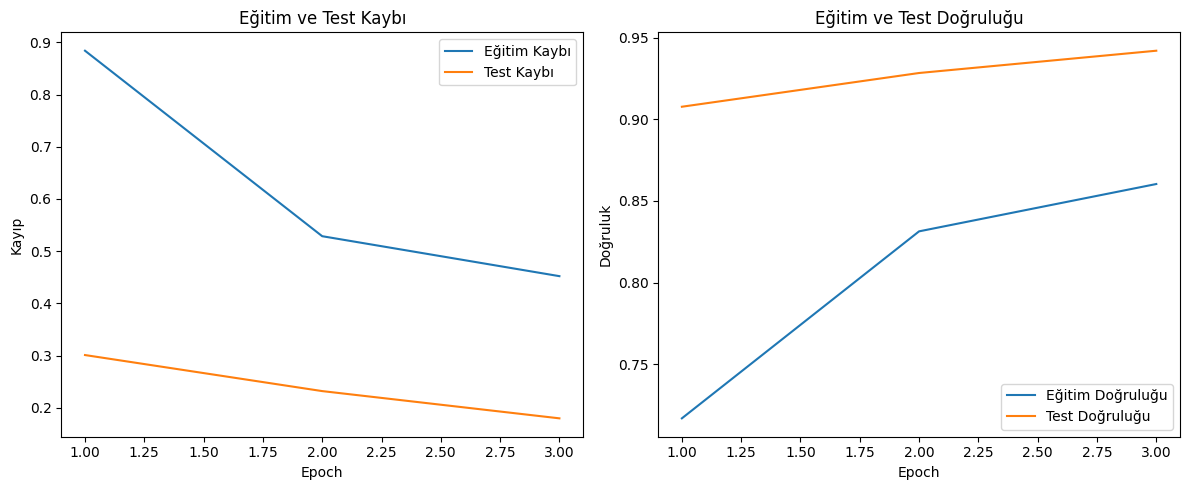

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_history, label='Eğitim Kaybı')
plt.plot(epochs_range, test_losses_history, label='Test Kaybı')
plt.title('Eğitim ve Test Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies_history, label='Eğitim Doğruluğu')
plt.plot(epochs_range, test_accuracies_history, label='Test Doğruluğu')
plt.title('Eğitim ve Test Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

plt.tight_layout()
plt.show()
